In [6]:
# ==========================================
# KNN: Predicting if a Patient is Diabetic
# User provides input at runtime
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1) Training Dataset
# ----------------------------
data = pd.DataFrame({
    "Patient": ["A", "B", "C", "D", "E", "F"],
    "Glucose": [80, 90, 100, 120, 140, 150],
    "BMI":     [22, 25, 28, 27, 30, 35],
    "Diabetic": ["No", "No", "No", "Yes", "Yes", "Yes"]
})

print("Training Dataset:")
display(data)


Training Dataset:


,Patient,Glucose,BMI,Diabetic
0,A,80,22,No
1,B,90,25,No
2,C,100,28,No
3,D,120,27,Yes
4,E,140,30,Yes
5,F,150,35,Yes


In [7]:
# ----------------------------
# 2) Take User Input
# ----------------------------
print("\nEnter details for the new patient:")

glucose_input = float(input("Enter Glucose level (mg/dL): "))
bmi_input = float(input("Enter BMI: "))

query = np.array([glucose_input, bmi_input])

print(f"\nNew Patient Q = (Glucose={query[0]}, BMI={query[1]})")


Enter details for the new patient:
Enter Glucose level (mg/dL): 130
Enter BMI: 29

New Patient Q = (Glucose=130.0, BMI=29.0)


In [8]:
# ----------------------------
# 3) KNN From Scratch
# ----------------------------
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(df, query_point, k=3):
    X = df[["Glucose", "BMI"]].values
    y = df["Diabetic"].values

    distances = []
    for i in range(len(X)):
        d = euclidean_distance(query_point, X[i])
        distances.append(d)

    result_df = df.copy()
    result_df["Distance"] = distances
    result_df = result_df.sort_values("Distance")

    neighbors = result_df.head(k)

    prediction = neighbors["Diabetic"].mode()[0]
    return prediction, result_df, neighbors

In [9]:
# Choose k
k = 3

prediction, all_distances, nearest_neighbors = knn_predict(data, query, k)

In [10]:
# ----------------------------
# 4) Results
# ----------------------------
print(f"\n--- KNN RESULTS (k = {k}) ---")
print("\nDistances from new patient:")
display(all_distances)

print(f"\n{k} Nearest Neighbors:")
display(nearest_neighbors)

print(f"\nFinal Prediction: Patient is DIABETIC = {prediction}")



--- KNN RESULTS (k = 3) ---

Distances from new patient:


,Patient,Glucose,BMI,Diabetic,Distance
4,E,140,30,Yes,10.049876
3,D,120,27,Yes,10.198039
5,F,150,35,Yes,20.880613
2,C,100,28,No,30.016662
1,B,90,25,No,40.199502
0,A,80,22,No,50.487622



3 Nearest Neighbors:


,Patient,Glucose,BMI,Diabetic,Distance
4,E,140,30,Yes,10.049876
3,D,120,27,Yes,10.198039
5,F,150,35,Yes,20.880613



Final Prediction: Patient is DIABETIC = Yes


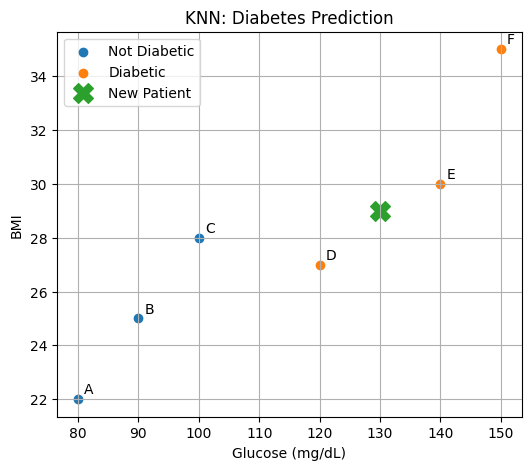

In [12]:
# ----------------------------
# 5) Visualization
# ----------------------------
yes = data[data["Diabetic"] == "Yes"]
no = data[data["Diabetic"] == "No"]

plt.figure(figsize=(6, 5))
plt.scatter(no["Glucose"], no["BMI"], label="Not Diabetic")
plt.scatter(yes["Glucose"], yes["BMI"], label="Diabetic")
plt.scatter(query[0], query[1], marker="X", s=200, label="New Patient")

for _, row in data.iterrows():
    plt.text(row["Glucose"] + 1, row["BMI"] + 0.2, row["Patient"])

plt.xlabel("Glucose (mg/dL)")
plt.ylabel("BMI")
plt.title("KNN: Diabetes Prediction")
plt.legend()
plt.grid(True)
plt.show()